# FADE 演示

本 Notebook 演示两个功能：
1. 用 `fade()` 计算三张测试图像的雾浓度分数
2. 用 `fade_with_map()` 生成并展示热力图

In [12]:
from pathlib import Path
import sys
import time

import numpy as np
from PIL import Image

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fade import fade

def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))

## 1. 计算三张图片的 FADE 分数

In [13]:
image_paths = [
    ROOT /  "test_image/test_image1.png",
    ROOT /  "test_image/test_image2.JPG",
    ROOT /  "test_image/test_image3.jpg",
]

print("image,shape,fade_score,elapsed_s")
for p in image_paths:
    if not p.exists():
        print(f"{p.name},MISSING,-,-")
        continue

    img = load_rgb(p)
    t0 = time.perf_counter()
    score = fade(img)
    dt = time.perf_counter() - t0
    print(f"{p.name},{img.shape},{score:.10f},{dt:.4f}")

image,shape,fade_score,elapsed_s


/Users/dongwei/JoeyDong/My_GitHub_Source/fade_py/src/fade/features/f03.py:20: RuntimeWarning: Degrees of freedom <= 0 for slice.
  return np.nanvar(tmp, axis=2, ddof=1)


test_image1.png,(768, 576, 3),0.9113393845,0.2224


/Users/dongwei/JoeyDong/My_GitHub_Source/fade_py/src/fade/features/f03.py:20: RuntimeWarning: Degrees of freedom <= 0 for slice.
  return np.nanvar(tmp, axis=2, ddof=1)


test_image2.JPG,(800, 600, 3),2.7121977531,0.2495
test_image3.jpg,(531, 800, 3),5.7674386227,0.2410


## 2. 热力图可视化

/Users/dongwei/JoeyDong/My_GitHub_Source/fade_py/src/fade/features/f03.py:20: RuntimeWarning: Degrees of freedom <= 0 for slice.
  return np.nanvar(tmp, axis=2, ddof=1)


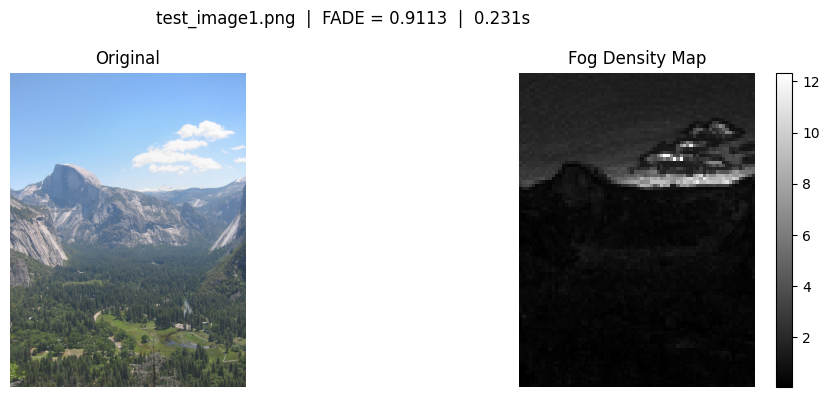

/Users/dongwei/JoeyDong/My_GitHub_Source/fade_py/src/fade/features/f03.py:20: RuntimeWarning: Degrees of freedom <= 0 for slice.
  return np.nanvar(tmp, axis=2, ddof=1)


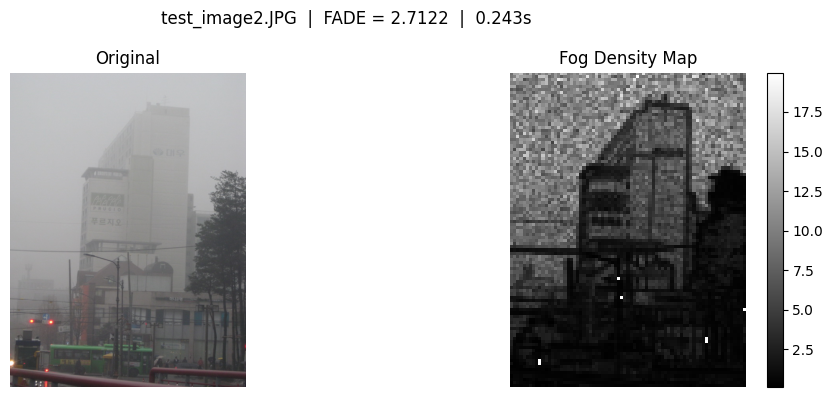

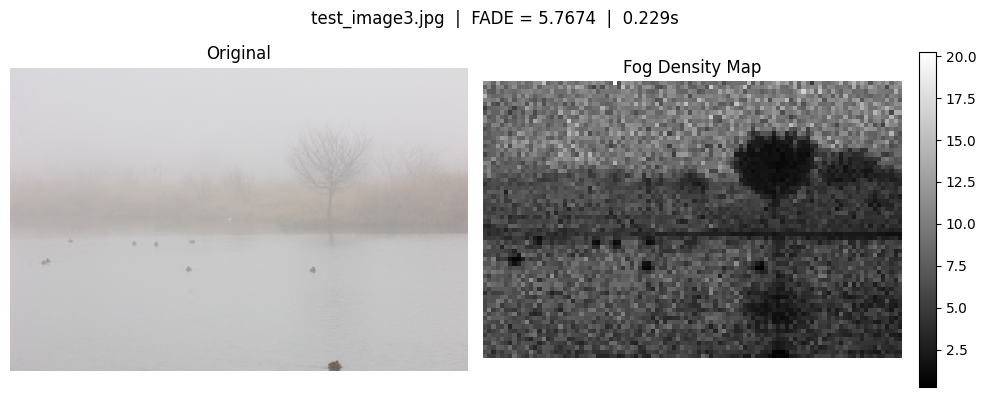

In [14]:
from fade import fade_with_map
from matplotlib import pyplot as plt

for p in image_paths:
    img = load_rgb(p)
    t0 = time.perf_counter()
    score, density_map = fade_with_map(img)
    dt = time.perf_counter() - t0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"{p.name}  |  FADE = {score:.4f}  |  {dt:.3f}s", fontsize=12)

    ax1.imshow(img)
    ax1.set_title("Original")
    ax1.axis("off")

    im = ax2.imshow(density_map, cmap="gray")
    ax2.set_title("Fog Density Map")
    ax2.axis("off")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()